# Phase 0: Set up (Runtime = 52s)

In [ ]:
#Runtime = 45s

# ============ BOOTSTRAP ============
import subprocess, sys, os
from google.colab import drive, userdata

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Load credentials from Colab Secrets
TOKEN = userdata.get('gitToken')
NAME  = userdata.get('gitName')
EMAIL = userdata.get('gitMail')

# 3. Git identity
!git config --global user.name "{NAME}"
!git config --global user.email "{EMAIL}"

# 4. Clone repo (skip if already cloned)
REPO_DIR = '/content/mit808-2026-project-data-insight-drivers'
if not os.path.exists(REPO_DIR):
    !git clone https://{TOKEN}@github.com/up-mitc-ds/mit808-2026-project-data-insight-drivers.git
else:
    print("Repo already cloned")

# 5. Switch to your branch and sync with master
os.chdir(REPO_DIR)
!git checkout kc/build_zones
!git fetch origin master
!git merge origin/master -m "Sync with master"

# 6. Install dependencies
subprocess.check_call([
    sys.executable, '-m', 'pip', 'install', '-q', '-r',
    os.path.join(REPO_DIR, 'requirements.txt')
])

# 7. Make src/ importable and configure environment
sys.path.insert(0, REPO_DIR)
from src.setup import configure_environment, PATHS, save_and_push
configure_environment()

print("✅ Bootstrap complete — repo at", REPO_DIR)

# ============ IMPORTS ============
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import rasterio
import geopandas as gpd
import earthpy.plot as ep
import contextily as ctx
import laspy
import os
from rasterio.windows import Window

In [ ]:
#Runtime = 0s

!git status

In [ ]:
#Runtime = 7s

# osmnx for OSM road network download
# scipy for Voronoi computation
# Both should already be in requirements.txt — this is a safety install
!pip install osmnx -q
import osmnx as ox
import scipy
print(f'osmnx {ox.__version__} | scipy {scipy.__version__}')

In [ ]:
#Runtime = 0s

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import osmnx as ox
import matplotlib.pyplot as plt

from shapely.geometry import Point, MultiPoint, box
from shapely.ops import unary_union, voronoi_diagram
from scipy.spatial import Voronoi
from pyproj import Transformer, CRS

# Suppress osmnx info logs
import logging
logging.getLogger('osmnx').setLevel(logging.WARNING)

print('All imports successful.')

#Phase 1: Load Data (Runtime = 3s)

In [ ]:
#Runtime = 2s

# ── CONFIG: update these column names to match your survey DataFrame ───────────
SURVEY_PATH  = r"/content/drive/MyDrive/MIT/MIT808/melusi-2025-data/processed/melusi_df.csv"           # adjust key if different
ZONE_COL     = 'Blocks'          # column identifying the zone (1–15)
COORD_COL_1  = 'Latitude'            # first coordinate column  ← update
COORD_COL_2  = 'Longitude'           # second coordinate column ← update
# ──────────────────────────────────────────────────────────────────────────────

survey = pd.read_csv(SURVEY_PATH) if str(SURVEY_PATH).endswith('.csv') \
         else pd.read_stata(SURVEY_PATH)

# Extract one row per zone (the centroid coordinates should be identical
# for all rows within a zone)
centroids_raw = (
    survey[[ZONE_COL, COORD_COL_1, COORD_COL_2]]
    .dropna()
    .drop_duplicates(subset=ZONE_COL)
    .sort_values(ZONE_COL)
    .reset_index(drop=True)
)

print(f'Zones found: {len(centroids_raw)}')
print(centroids_raw.head(16))

In [ ]:
#Runtime = 0s

# Inspect all unique coordinate pairs with their block and dwelling info
coord_summary = survey.groupby(['Longitude', 'Latitude']).agg(
    Blocks=('Blocks', 'first'),
    Dwelling_count=('Dwelling_count', 'first'),  # adjust column name if needed
    Individuals=('Latitude', 'count')
).reset_index()

coord_summary = coord_summary.sort_values('Blocks')

print(f"Total unique coordinate pairs: {len(coord_summary)}")
print()
print(coord_summary.to_string(index=False))

# Flag suspicious coordinates
print("\n\nCOORDINATE QUALITY CHECK")
print("=" * 50)
print(f"Expected Longitude range: ~28.06 – 28.13")
print(f"Expected Latitude range:  ~-25.72 – -25.73")
print()

for _, row in coord_summary.iterrows():
    issues = []

    if not (28.0 < row['Longitude'] < 28.2):
        issues.append(f"Lon {row['Longitude']} outside expected range")

    if not (-25.8 < row['Latitude'] < -25.7):
        issues.append(f"Lat {row['Latitude']} outside expected range")

    if pd.isna(row['Blocks']) or str(row['Blocks']).strip() in ('', 'nan', 'N/A'):
        issues.append("No Block assigned")

    status = "⚠️ " + " | ".join(issues) if issues else "✅ OK"
    print(f"Block {str(row['Blocks']):>4} | Lon {row['Longitude']:>10} | Lat {row['Latitude']:>10} | {row['Individuals']:>5} people | {status}")

In [ ]:
#Runtime = 1s

# Define Melusi bounds from the orthophoto
with rasterio.open(PATHS["geotiff"]) as src:
    raster_bounds = src.bounds

# Convert raster bounds (Lo CRS) to WGS84 for comparison
# Melusi WGS84 approximate bounds based on the clean coordinate cluster:
melusi_lon_min, melusi_lon_max = 28.08, 28.14
melusi_lat_min, melusi_lat_max = -25.74, -25.71

# Flag suspect coordinates
before_count = len(survey)

suspect_mask = (
    (survey['Longitude'] < melusi_lon_min) | (survey['Longitude'] > melusi_lon_max) |
    (survey['Latitude'] < melusi_lat_min) | (survey['Latitude'] > melusi_lat_max) |
    pd.isna(survey['Blocks'])
)

suspect = survey[suspect_mask]
print(f"FLAGGED COORDINATES OUTSIDE MELUSI BOUNDS")
print(f"Lon bounds: {melusi_lon_min} – {melusi_lon_max}")
print(f"Lat bounds: {melusi_lat_min} – {melusi_lat_max}")
print(f"=" * 50)
print(f"Suspect rows: {suspect_mask.sum()} / {before_count}")
print()

# Show what's being removed
if len(suspect) > 0:
    print(suspect.groupby(['Blocks', 'Longitude', 'Latitude']).size().reset_index(name='Individuals').to_string(index=False))

# Remove suspect rows
survey_clean = survey[~suspect_mask].copy()
print(f"\nBefore: {before_count:,} rows")
print(f"After:  {len(survey_clean):,} rows")
print(f"Removed: {before_count - len(survey_clean):,} rows")

# Replace original survey so downstream code is unaffected
survey = survey_clean

In [ ]:
#Runtime = 0s

coord_summary = survey.groupby(['Longitude', 'Latitude']).agg(
    Blocks=('Blocks', 'first'),
    Dwelling_count=('Dwelling_count', 'first'),  # adjust column name if needed
    Individuals=('Latitude', 'count')
).reset_index()

coord_summary = coord_summary.sort_values('Blocks')

print(f"Total unique coordinate pairs: {len(coord_summary)}")

#Phase 2: Detect CRS, Build GDF, and Reproject Centriods (Runtime = 1s)

In [ ]:
#Runtime = 0s

c1_vals = centroids_raw[COORD_COL_1].values
c2_vals = centroids_raw[COORD_COL_2].values

def detect_crs(c1, c2):
    """
    Heuristic CRS detection based on coordinate magnitude.
    Lo29 (EPSG:2053): Y ~2,840,000–2,850,000 | X ~87,000–91,000
    WGS84 (EPSG:4326): lat ~-25 to -26    | lon ~28 to 29
    """
    # Check if values look like Lo29 projected (large positive integers)
    if abs(c1[0]) > 1_000_000 or abs(c2[0]) > 1_000_000:
        detected = 'Lo29 (EPSG:2053)'
        epsg = 2053
        # In Lo29, convention is (Y_northing, X_easting)
        # Y is the large value (~2.8M), X is smaller (~88K)
        if abs(c1[0]) > abs(c2[0]):
            northing_col, easting_col = COORD_COL_1, COORD_COL_2
        else:
            northing_col, easting_col = COORD_COL_2, COORD_COL_1
    # Check if values look like WGS84 degrees
    elif -90 <= c1[0] <= 90 and -180 <= c2[0] <= 180:
        detected = 'WGS84 (EPSG:4326)'
        epsg = 4326
        # Convention: (latitude, longitude)
        if c1[0] < 0:   # negative = southern hemisphere = latitude
            northing_col, easting_col = COORD_COL_1, COORD_COL_2
        else:
            northing_col, easting_col = COORD_COL_2, COORD_COL_1
    else:
        detected = 'Unknown'
        epsg = None
        northing_col, easting_col = COORD_COL_1, COORD_COL_2

    return detected, epsg, northing_col, easting_col

detected_crs, source_epsg, northing_col, easting_col = detect_crs(c1_vals, c2_vals)

print(f'Detected CRS : {detected_crs}')
print(f'Northing col : {northing_col}  (sample: {centroids_raw[northing_col].values[:3]})')
print(f'Easting col  : {easting_col}   (sample: {centroids_raw[easting_col].values[:3]})')
print()
print('>>> If this looks wrong, manually set source_epsg, northing_col, easting_col below.')

# ── MANUAL OVERRIDE (uncomment and edit if auto-detection was wrong) ───────────
# source_epsg  = 2053
# northing_col = 'gps_latitude'
# easting_col  = 'gps_longitude'
# ──────────────────────────────────────────────────────────────────────────────

In [ ]:
#Runtime = 0s

# Build GeoDataFrame in source CRS
geometry = [
    Point(row[easting_col], row[northing_col])
    for _, row in centroids_raw.iterrows()
]
gdf_centroids = gpd.GeoDataFrame(
    centroids_raw[[ZONE_COL]].copy(),
    geometry=geometry,
    crs=f'EPSG:{source_epsg}'
)

# Reproject to WGS84 for OSM download
gdf_centroids_wgs = gdf_centroids.to_crs('EPSG:4326')

# Reproject to Lo29 for metric operations
gdf_centroids_lo29 = gdf_centroids.to_crs('EPSG:2053')

print('Centroids in WGS84:')
print(gdf_centroids_wgs[['Blocks', 'geometry']].to_string())

#Phase 3: Define Melusi Boundaries from GeoTiff (Runtime = 1s)

In [ ]:
#Runtime = 0s

# Try GeoTIFF first, fall back to ECW
raster_path = None
for key in ['geotiff', 'ecw']:
    if key in PATHS and os.path.exists(PATHS[key]):
        raster_path = PATHS[key]
        print(f'Using raster: {key} → {raster_path}')
        break

if raster_path is None:
    raise FileNotFoundError(
        'Neither geotiff nor ecw found in PATHS. '
        'Check that Google Drive is mounted and PATHS keys are correct.'
    )

with rasterio.open(raster_path) as src:
    bounds = src.bounds
    raster_crs = src.crs
    print(f'Raster CRS   : {raster_crs}')
    print(f'Raster bounds: {bounds}')

# --- CRS handling (robust to malformed axis definitions) ---
def resolve_crs(crs):
    """Return a safe CRS, overriding known problematic definitions."""
    if crs is None:
        print('CRS missing → assuming EPSG:2053 (Lo29)')
        return 'EPSG:2053'

    crs_str = crs.to_string()

    # Detect problematic South-orientated CRS
    if 'South_Orientated' in crs_str or 'AXIS' in crs_str:
        print('Non-standard CRS detected → overriding to EPSG:2053 (Lo29)')
        return 'EPSG:2053'

    return crs

safe_crs = resolve_crs(raster_crs)

# Build boundary polygon
settlement_bbox = box(bounds.left, bounds.bottom, bounds.right, bounds.top)
gdf_boundary_native = gpd.GeoDataFrame(
    {'id': [1]},
    geometry=[settlement_bbox],
    crs=safe_crs
)

# Reproject
gdf_boundary_wgs  = gdf_boundary_native.to_crs('EPSG:4326')
gdf_boundary_lo29 = gdf_boundary_native.to_crs('EPSG:2053')

print('\nBoundary in WGS84 bounds:', gdf_boundary_wgs.total_bounds)

#Phase 4: OSM Section (Runtime = 5s)

In [ ]:
#Runtime = 0s

import osmnx as ox
import geopandas as gpd

# Load the OSM XML file from Drive
osm_path = PATHS["data_raw"] + "melusi_osm"

# Check if it needs the .xml extension
print(os.path.exists(osm_path))
print(os.path.exists(osm_path + ".xml"))

In [ ]:
#Runtime = 4s

# Load graph from local OSM XML file
G = ox.graph_from_xml(osm_path)

print(f"Nodes: {len(G.nodes)}")
print(f"Edges: {len(G.edges)}")

# Convert to GeoDataFrame
edges_wgs = ox.graph_to_gdfs(G, nodes=False, edges=True)
print(f"Road segments: {len(edges_wgs)}")
print(f"Highway types: {edges_wgs['highway'].explode().unique()}")

In [ ]:
#Runtime = 0s

# Reproject edges to Lo29 for metric operations
edges_lo29 = edges_wgs.to_crs('EPSG:2053')

# Clip to settlement boundary (removes roads outside the orthophoto extent)
edges_lo29 = gpd.clip(edges_lo29, gdf_boundary_lo29)
print(f'Edges after clipping to settlement: {len(edges_lo29)}')

#Phase 5: Densify and assign roads (Runtime = 2s)

In [ ]:
#Runtime = ~2s

from shapely.ops import polygonize, unary_union
from shapely.geometry import MultiLineString

# ── Polygonize the road network into enclosed faces ─────────────────────────
# This forces every block boundary to follow a road edge.
# No boundary can bisect a dwelling unless a road runs through it.

# Collect all road geometries and the settlement boundary ring
road_lines = []
for geom in edges_lo29.geometry:
    if geom.geom_type == "LineString":
        road_lines.append(geom)
    elif geom.geom_type == "MultiLineString":
        road_lines.extend(geom.geoms)

# Include the settlement bbox boundary as a closing ring
# so peripheral roads form closed faces
boundary_poly = gdf_boundary_lo29.geometry.iloc[0]
road_lines.append(boundary_poly.exterior)

# Node (split at intersections) then polygonize
merged = unary_union(road_lines)  # auto-nodes at intersections
faces = list(polygonize(merged))

print(f"Road segments fed to polygonize: {len(road_lines):,}")
print(f"Enclosed faces produced: {len(faces)}")

# Build GeoDataFrame of faces
gdf_faces = gpd.GeoDataFrame(
    {"face_id": range(len(faces))},
    geometry=faces,
    crs="EPSG:2053"
)


In [ ]:
#Runtime = ~1s

from scipy.spatial import cKDTree

# Extract centroid coordinates in Lo29 as array
centroid_coords = np.array([
    [pt.x, pt.y] for pt in gdf_centroids_lo29.geometry
])
zone_ids = gdf_centroids_lo29[ZONE_COL].values

# Build KD-tree for fast nearest-neighbour lookup
tree = cKDTree(centroid_coords)

# ── Assign each road-network face to a zone ─────────────────────────────────
# Use representative_point() — guaranteed inside the polygon, safer than
# centroid for concave faces.
face_rep_pts = np.array([
    [f.representative_point().x, f.representative_point().y]
    for f in gdf_faces.geometry
])
_, nearest_idx = tree.query(face_rep_pts)
gdf_faces[ZONE_COL] = zone_ids[nearest_idx]

print(f"Faces assigned to zones. Distribution:")
print(gdf_faces[ZONE_COL].value_counts().sort_index())


#Phase 6: Dissolve Road Faces into Zone Polygons (Runtime = ~2s)


In [ ]:
#Runtime = ~2s

# Dissolve adjacent faces with the same zone label into zone polygons
gdf_zones_raw = (
    gdf_faces
    .dissolve(by=ZONE_COL)
    .reset_index()
    .clip(gdf_boundary_lo29)
)

print(f"Zone polygons produced: {len(gdf_zones_raw)}")
for _, row in gdf_zones_raw.iterrows():
    g = row.geometry
    n_parts = len(g.geoms) if g.geom_type == "MultiPolygon" else 1
    print(f"  Block {int(row[ZONE_COL]):>3} | {g.geom_type:<15} | {n_parts} parts | area: {g.area:,.0f} m²")


In [ ]:
# ── Reassign orphan fragments to adjacent zones ────────────────────────────
# After dissolve, some zones are MultiPolygons with disconnected fragments.
# Strategy:
#   1. Explode MultiPolygons into individual parts
#   2. Tag the largest part per zone as the "core"
#   3. For each orphan, find which core zone shares the longest boundary
#   4. Reassign orphan → that adjacent core zone
#   5. Re-dissolve

from shapely.geometry import MultiPolygon

# Step 1: Explode into individual polygon parts
parts = []
for _, row in gdf_zones_raw.iterrows():
    zone_id = row[ZONE_COL]
    geom = row.geometry
    if geom.geom_type == "MultiPolygon":
        for part in geom.geoms:
            parts.append({"zone_id": zone_id, "geometry": part, "area": part.area})
    else:
        parts.append({"zone_id": zone_id, "geometry": geom, "area": geom.area})

gdf_parts = gpd.GeoDataFrame(parts, crs="EPSG:2053")
print(f"Total polygon parts after explode: {len(gdf_parts)}")

# Step 2: Tag largest part per zone as "core"
core_idx = gdf_parts.groupby("zone_id")["area"].idxmax()
gdf_parts["is_core"] = False
gdf_parts.loc[core_idx, "is_core"] = True

cores = gdf_parts[gdf_parts["is_core"]].copy()
orphans = gdf_parts[~gdf_parts["is_core"]].copy()
print(f"Core polygons: {len(cores)}, Orphan fragments: {len(orphans)}")

# Step 3 & 4: Reassign each orphan to the core zone it shares the longest
# boundary with. Use a small buffer to catch near-touches (road-width gaps).
TOUCH_BUFFER_M = 1.0  # ~1m tolerance for shared-edge detection

reassigned = 0
for idx, orphan_row in orphans.iterrows():
    orphan_geom = orphan_row.geometry.buffer(TOUCH_BUFFER_M)
    best_zone = orphan_row.zone_id  # fallback: keep original
    best_shared = 0.0

    for _, core_row in cores.iterrows():
        shared = orphan_geom.intersection(core_row.geometry).length
        if shared > best_shared:
            best_shared = shared
            best_zone = core_row.zone_id

    if best_zone != orphan_row.zone_id:
        old = int(orphan_row.zone_id)
        new = int(best_zone)
        print(f"  Orphan (area {orphan_row.area:,.0f} m²): B{old} → B{new} (shared edge: {best_shared:.1f}m)")
        gdf_parts.loc[idx, "zone_id"] = best_zone
        reassigned += 1
    else:
        print(f"  Orphan (area {orphan_row.area:,.0f} m²): B{int(best_zone)} → kept (no adjacent core found)")

print(f"\nReassigned {reassigned}/{len(orphans)} orphan fragments")

# Step 5: Re-dissolve with corrected assignments
gdf_zones_lo29 = (
    gdf_parts[["zone_id", "geometry"]]
    .rename(columns={"zone_id": ZONE_COL})
    .dissolve(by=ZONE_COL)
    .reset_index()
)

# Final diagnostic
print(f"\nFinal zone polygons: {len(gdf_zones_lo29)}")
for _, row in gdf_zones_lo29.iterrows():
    g = row.geometry
    n_parts = len(g.geoms) if g.geom_type == "MultiPolygon" else 1
    gtype = "✅" if n_parts == 1 else f"⚠️  {n_parts} parts"
    print(f"  Block {int(row[ZONE_COL]):>3} | area: {g.area:,.0f} m² | {gtype}")

In [ ]:
#Runtime = 0s

# Area in square metres (Lo29 is a metric CRS)
gdf_zones_lo29['area_m2'] = gdf_zones_lo29.geometry.area
gdf_zones_lo29['area_ha'] = gdf_zones_lo29['area_m2'] / 10_000

# WGS84 version for web mapping / OSM overlays
gdf_zones_wgs = gdf_zones_lo29.to_crs('EPSG:4326')

print('Zone area summary (hectares):')
print(gdf_zones_lo29[['Blocks', 'area_m2']].to_string(index=False))
print(f'\nTotal area: {gdf_zones_lo29["area_m2"].sum():.2f} m^2')

In [ ]:
from shapely.geometry import shape
from rasterio.features import shapes

with rasterio.open(PATHS["geotiff"]) as src:
    # Read downsampled brightness to create a data mask
    scale = 100
    small = src.read(
        [1, 2, 3],
        out_shape=(3, src.height // scale, src.width // scale)
    )

    # Mask: pixels where NOT all bands are 255 (i.e., actual data)
    brightness = small.mean(axis=0)
    data_mask = (brightness < 250).astype(np.uint8)

    # Get the transform for the downsampled resolution
    transform = src.transform * src.transform.scale(
        src.width / (src.width // scale),
        src.height / (src.height // scale)
    )

    # Convert mask to polygon
    mask_shapes = list(shapes(data_mask, mask=data_mask == 1, transform=transform))

    # Take the largest polygon (the main settlement footprint)
    polys = [shape(s) for s, v in mask_shapes]
    data_boundary_raw = max(polys, key=lambda p: p.area)

# ── Smooth the raster-traced boundary ──────────────────────────────────────
# Buffer out then back in removes the pixel-staircase jaggedness.
# 5m chosen as ~2x the downsampled pixel size — enough to fuse staircase
# teeth without eroding narrow settlement fingers.
SMOOTH_BUFFER_M = 5.0
data_boundary = (
    data_boundary_raw
    .buffer(SMOOTH_BUFFER_M)
    .buffer(-SMOOTH_BUFFER_M)
)

area_change_pct = abs(data_boundary.area - data_boundary_raw.area) / data_boundary_raw.area * 100
print(f"Raw boundary area:      {data_boundary_raw.area:,.0f} m²")
print(f"Smoothed boundary area: {data_boundary.area:,.0f} m²")
print(f"Area change from smoothing: {area_change_pct:.2f}%")

# Create GeoDataFrame of the smoothed data boundary
gdf_data_boundary = gpd.GeoDataFrame(
    geometry=[data_boundary],
    crs=src.crs
)

print(f"\nData boundary area: {data_boundary.area:,.0f} m²")
print(f"Data boundary area: {data_boundary.area / 10000:.1f} hectares")

# Re-clip the zone polygons to the smoothed data boundary
gdf_zones_clipped = gdf_zones_lo29.copy()
gdf_zones_clipped['geometry'] = gdf_zones_clipped.geometry.intersection(data_boundary)

# Remove any empty geometries
gdf_zones_clipped = gdf_zones_clipped[~gdf_zones_clipped.is_empty]

print(f"Zones clipped to data boundary: {len(gdf_zones_clipped)}")


#Phase 7: Validation Plot (Runtime = 5s)

In [ ]:
import matplotlib.patches as mpatches
from matplotlib.cm import get_cmap

fig, axes = plt.subplots(1, 2, figsize=(18, 9))
cmap = get_cmap('tab20', len(gdf_zones_clipped))

# ── Left: Zones with road network overlay ─────────────────────────────────────
ax = axes[0]
gdf_zones_clipped.plot(ax=ax, column=ZONE_COL, cmap='tab20',
                       alpha=0.5, edgecolor='black', linewidth=0.8)
edges_lo29.plot(ax=ax, color='grey', linewidth=0.4, alpha=0.7, label='OSM roads')

# Label zones
for _, row in gdf_zones_clipped.iterrows():
    if row.geometry.is_empty:
        continue
    centroid = row.geometry.centroid
    ax.text(
        centroid.x, centroid.y,
        f"B{int(row[ZONE_COL])}",
        fontsize=9, fontweight='bold', color='white',
        ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.8)
    )

ax.set_title('Road-Constrained Voronoi Zone Boundaries\n(Lo29 EPSG:2053)', fontsize=11)
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')
ax.legend()

# ── Right: Zone areas bar chart ────────────────────────────────────────────────
ax2 = axes[1]

# Recalculate areas from clipped zones
gdf_zones_clipped['area_ha'] = gdf_zones_clipped.geometry.area / 10000

sorted_zones = gdf_zones_clipped.sort_values(ZONE_COL)
bars = ax2.bar(
    sorted_zones[ZONE_COL].astype(int).astype(str),
    sorted_zones['area_ha'],
    color=[cmap(i) for i in range(len(sorted_zones))],
    edgecolor='black', linewidth=0.5
)
ax2.set_title('Block Area Comparison\n(Approximate — boundary assumption applies)', fontsize=11)
ax2.set_xlabel('Blocks')
ax2.set_ylabel('Area (hectares)')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(PATHS["figures"] + "/zone_boundaries_validation.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
#Runtime = 0s

import os
os.makedirs('data/processed', exist_ok=True)

# Lo29 — primary working CRS (metric, matches orthophoto and LiDAR)
out_lo29 = 'data/processed/zone_boundaries_lo29.geojson'
gdf_zones_lo29.to_file(out_lo29, driver='GeoJSON')
print(f'Saved (Lo29):  {out_lo29}')

# WGS84 — for web mapping and OSM overlay
out_wgs = 'data/processed/zone_boundaries_wgs84.geojson'
gdf_zones_wgs.to_file(out_wgs, driver='GeoJSON')
print(f'Saved (WGS84): {out_wgs}')

# Zone centroid points (useful for later joins)
out_centroids = 'data/processed/zone_centroids_lo29.geojson'
gdf_centroids_lo29.to_file(out_centroids, driver='GeoJSON')
print(f'Saved centroids: {out_centroids}')

In [ ]:
fig, ax = plt.subplots(figsize=(16, 8))

ax.imshow(
    np.moveaxis(small, 0, -1),
    extent=[src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top],
    origin='upper'
)

# Draw zone boundaries
for _, row in gdf_zones_clipped.iterrows():
    geom = row.geometry
    if geom.is_empty:
        continue
    if geom.geom_type == 'MultiPolygon':
        polys = list(geom.geoms)
    else:
        polys = [geom]
    for poly in polys:
        xs, ys = poly.exterior.xy
        ax.plot(xs, ys, color='red', linewidth=2)

# Labels — larger, white text on black background
for _, row in gdf_zones_clipped.iterrows():
    if row.geometry.is_empty:
        continue
    centroid = row.geometry.centroid
    ax.text(
        centroid.x, centroid.y,
        f"B{int(row[ZONE_COL])}",
        fontsize=12, fontweight='bold', color='white',
        ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.8, edgecolor='red')
    )

ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')
ax.set_title('Road-Constrained Voronoi Zones — Clipped to Data Boundary')
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig(PATHS["figures"] + "/voronoi_clipped_clean.jpg", dpi=150, format='jpeg')
plt.show()

#Debug

B1 centroid: (89590.9, 2846752.3)
B1 faces before orphan fix: 14, total area: 48,333 m²
B1 faces after orphan fix:  1, total area: 29,540 m²

B1 neighbours (shared boundary):
  B2: 157.0m shared edge
  B5: 45.0m shared edge
  B10: 790.6m shared edge

Distance from B1 centroid to others:
  B2: 204m
  B3: 963m
  B4: 2,045m
  B5: 286m
  B6: 811m
  B7: 617m
  B8: 899m
  B9: 748m
  B10: 234m
  B11: 1,925m
  B12: 1,505m


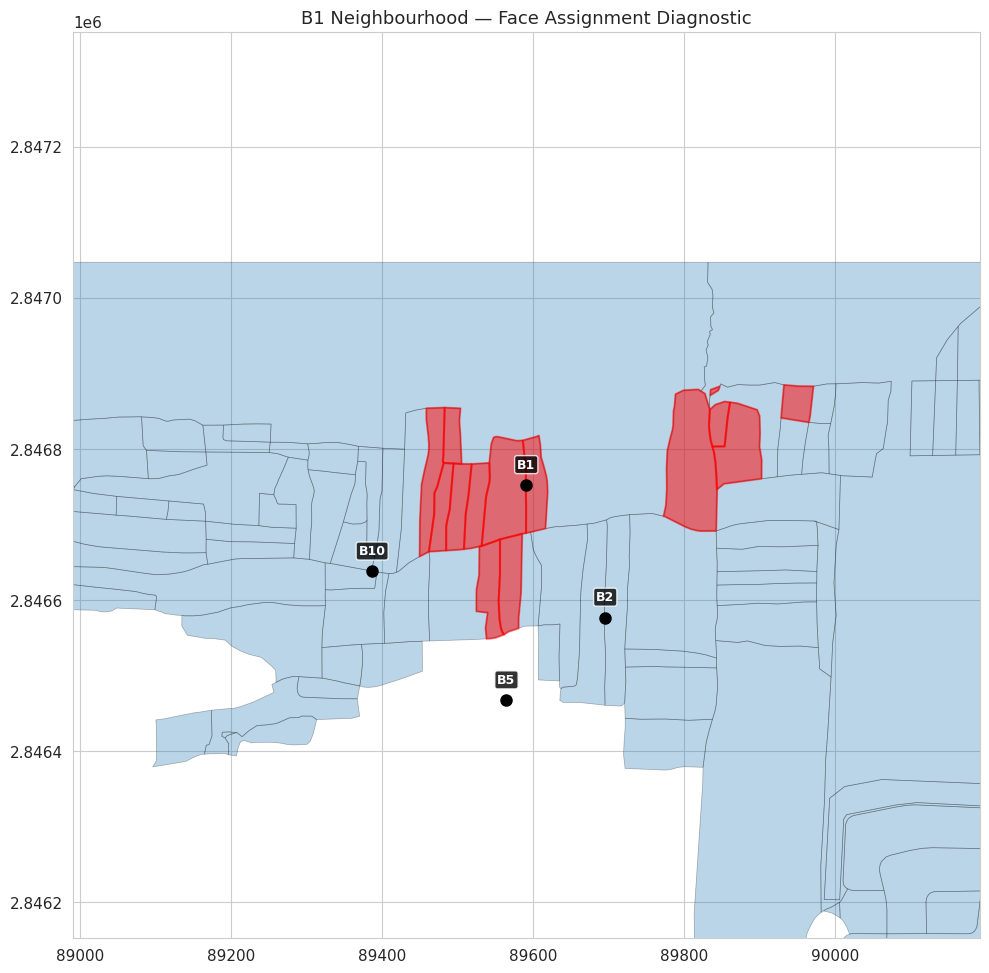

In [34]:
# ── B1 Diagnostic: Why is it so small? ────────────────────────────────────────

b1_id = 1.0
b1_centroid = gdf_centroids_lo29.loc[gdf_centroids_lo29[ZONE_COL] == b1_id, 'geometry'].iloc[0]

# How many faces were originally assigned to B1 before orphan reassignment?
b1_faces_original = gdf_faces[gdf_faces[ZONE_COL] == b1_id]
b1_faces_final = gdf_parts[gdf_parts['zone_id'] == b1_id]

print(f"B1 centroid: ({b1_centroid.x:.1f}, {b1_centroid.y:.1f})")
print(f"B1 faces before orphan fix: {len(b1_faces_original)}, total area: {b1_faces_original.geometry.area.sum():,.0f} m²")
print(f"B1 faces after orphan fix:  {len(b1_faces_final)}, total area: {b1_faces_final.geometry.area.sum():,.0f} m²")

# Which zones are B1's neighbours?
b1_zone = gdf_zones_lo29.loc[gdf_zones_lo29[ZONE_COL] == b1_id, 'geometry'].iloc[0]
print(f"\nB1 neighbours (shared boundary):")
for _, row in gdf_zones_lo29.iterrows():
    if row[ZONE_COL] == b1_id:
        continue
    shared = b1_zone.intersection(row.geometry).length
    if shared > 0:
        print(f"  B{int(row[ZONE_COL])}: {shared:.1f}m shared edge")

# Distance from B1 centroid to all other centroids
print(f"\nDistance from B1 centroid to others:")
for _, row in gdf_centroids_lo29.iterrows():
    if row[ZONE_COL] == b1_id:
        continue
    dist = b1_centroid.distance(row.geometry)
    print(f"  B{int(row[ZONE_COL])}: {dist:,.0f}m")

# Plot zoom on B1 area
fig, ax = plt.subplots(figsize=(10, 10))
# Plot all faces in B1 neighbourhood, coloured by zone
for zone_id in [1, 2, 7, 9, 10]:
    subset = gdf_faces[gdf_faces[ZONE_COL] == zone_id]
    if len(subset) > 0:
        subset.plot(ax=ax, alpha=0.3, edgecolor='black', linewidth=0.5, label=f'B{zone_id}')

# Highlight B1 core
b1_faces_original.plot(ax=ax, color='red', alpha=0.5, edgecolor='red', linewidth=1.5)

# Plot all centroids in area
for _, row in gdf_centroids_lo29.iterrows():
    ax.plot(row.geometry.x, row.geometry.y, 'ko', markersize=8)
    ax.annotate(f"B{int(row[ZONE_COL])}", (row.geometry.x, row.geometry.y),
                fontsize=9, fontweight='bold', color='white',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.8),
                ha='center', va='bottom', xytext=(0, 10), textcoords='offset points')

# Zoom to B1 neighbourhood
cx, cy = b1_centroid.x, b1_centroid.y
ax.set_xlim(cx - 600, cx + 600)
ax.set_ylim(cy - 600, cy + 600)
ax.set_title('B1 Neighbourhood — Face Assignment Diagnostic')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

In [ ]:
print(f"Unique zone IDs: {sorted(gdf_zones_lo29[ZONE_COL].unique())}")
print(f"Count: {len(gdf_zones_lo29)}")
print()
for _, row in gdf_zones_lo29.iterrows():
    g = row.geometry
    n_parts = len(g.geoms) if g.geom_type == 'MultiPolygon' else 1
    print(f"Block {int(row[ZONE_COL]):>3} | {g.geom_type:<15} | {n_parts} parts | area: {g.area:,.0f} m²")

In [ ]:
# ============ SAVE VORONOI POLYGONS TO GDRIVE ============
import os

# Save path (adjust variable name to match your GeoDataFrame)
SAVE_DIR = '/content/drive/MyDrive/MIT/MIT808/melusi-2025-data/processed'
os.makedirs(SAVE_DIR, exist_ok=True)

# Save polygons (change 'voronoi_gdf' to whatever your variable is called)
gdf_zones_clipped.to_file(os.path.join(SAVE_DIR, 'voronoi_blocks.gpkg'), driver='GPKG')
print(f"✅ Saved {len(gdf_zones_clipped)} blocks to {SAVE_DIR}/voronoi_blocks.gpkg")

# Save centroids separately (stays on Drive only — not committed to GitHub)
centroids_gdf = gdf_zones_clipped.copy()
centroids_gdf['geometry'] = centroids_gdf.geometry.centroid
centroids_gdf.to_file(os.path.join(SAVE_DIR, 'block_centroids.gpkg'), driver='GPKG')
print(f"✅ Saved centroids to {SAVE_DIR}/block_centroids.gpkg")

In [ ]:
# 1. Push the clean branch to the CLASS repo
!git checkout kc/build_zones_clean
!git push https://{TOKEN}@github.com/up-mitc-ds/mit808-2026-project-data-insight-drivers.git kc/build_zones_clean

# 2. Merge into master
!git checkout master
!git pull origin master
!git merge kc/build_zones_clean --allow-unrelated-histories -m "Merge Stage 0: Voronoi block boundaries"
!git push https://{TOKEN}@github.com/up-mitc-ds/mit808-2026-project-data-insight-drivers.git master

# 3. Create modelling branch from updated master
!git checkout -b kampamba/modelling_v2
!git push https://{TOKEN}@github.com/up-mitc-ds/mit808-2026-project-data-insight-drivers.git kampamba/modelling_v2

In [ ]:
!echo "__pycache__/" >> .gitignore
!git rm -r --cached src/__pycache__/
!git commit -m "chore: remove pycache from tracking"
!git push https://{TOKEN}@github.com/up-mitc-ds/mit808-2026-project-data-insight-drivers.git kampamba/modelling_v2

In [ ]:
# What zones do we have in the Voronoi output?
print("Zones in Voronoi:", sorted(gdf_centroids_lo29['Dwelling_count'].unique()))
print(f"Count: {len(gdf_centroids_lo29)}")

# What zones should we have from the survey?
expected = sorted(survey['Dwelling_count'].unique())
print(f"\nExpected zones: {expected}")
print(f"Count: {len(expected)}")

# Which one is missing?
missing = set(expected) - set(gdf_centroids_lo29['Dwelling_count'].unique())
print(f"\nMissing zone(s): {missing}")

In [ ]:
# Check which Dwelling_counts are in the Voronoi but not in the clean survey
extra = set(gdf_centroids_lo29['Dwelling_count'].unique()) - set(survey_clean['Dwelling_count'].unique())
print(f"Extra zones to remove: {extra}")



In [ ]:
print(coord_summary[['Blocks', 'Dwelling_count', 'Longitude', 'Latitude', 'Individuals']].to_string(index=False))

In [ ]:
# Check how far back the bad commit is
!git log --oneline | head -20

In [ ]:
# 1. Abort any in-progress cherry-pick
!git cherry-pick --abort 2>/dev/null

# 2. Go back to the original branch to grab your finished files
!git checkout kc/build_zones

# 3. Copy your final files to a safe location OUTSIDE the repo
!mkdir -p /content/clean_backup
!cp -r notebooks/ /content/clean_backup/notebooks/
!cp -r reports/ /content/clean_backup/reports/
!cp -r src/ /content/clean_backup/src/
!cp -r data/ /content/clean_backup/data/ 2>/dev/null
!cp requirements.txt /content/clean_backup/ 2>/dev/null

In [ ]:
# 4. Create an orphan branch (no parent commits = no history at all)
!git checkout --orphan kc/build_zones_clean

# 5. Remove everything from the staging area
!git rm -rf .

# 6. Copy your clean files back in
!cp -r /content/clean_backup/* .

# 7. Make sure the notebook has cleared outputs
# (You should have already done this manually in Colab)

# 8. Commit — this is a single fresh commit with zero history
!git add -A
!git commit -m "Stage 0: finalise Voronoi block boundaries"

# 9. Push
!git push https://{TOKEN}@github.com/MrChanda/melusi-2025.git kc/build_zones_clean

In [ ]:
# 1. Switch to master
!git checkout master

# 2. Pull latest
!git pull https://{TOKEN}@github.com/MrChanda/melusi-2025.git master

# 3. Merge your clean branch (--allow-unrelated-histories because the orphan branch has no shared ancestor)
!git merge kc/build_zones_clean --allow-unrelated-histories -m "Merge Stage 0: Voronoi block boundaries"

# 4. Push updated master
!git push https://{TOKEN}@github.com/MrChanda/melusi-2025.git master

# 5. Create your modelling branch
!git checkout -b kampamba/modelling

# 6. Push it
!git push https://{TOKEN}@github.com/MrChanda/melusi-2025.git kampamba/modelling

In [ ]:
# Rename local master to main
!git checkout master
!git branch -m master main

# Push main (this updates the existing main on GitHub)
!git push https://{TOKEN}@github.com/MrChanda/melusi-2025.git main --force

# Delete the stale master branch from GitHub
!git push https://{TOKEN}@github.com/MrChanda/melusi-2025.git --delete master

# Update kampamba/modelling to track from main
!git checkout kampamba/modelling
!git push https://{TOKEN}@github.com/MrChanda/melusi-2025.git kampamba/modelling

#Phase X: Git -push and -Commit

In [ ]:
save_and_push("kc_boundaries.ipynb", "Fixed save for Block polygons")